# IndoBERT - Balanced Dataset dengan Data Augmentation



In [ ]:
!pip install -q PySastrawi emoji transformers torch scikit-learn seaborn nlpaug

import os, re, json, pickle, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Library siap")
print(f"   PyTorch  : {torch.__version__}")
print(f"   CUDA     : {torch.cuda.is_available()}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 23.9 MB/s eta 0:00:00
Library siap
   PyTorch  : 2.11.0+cu128
   CUDA     : True


In [ ]:
import shutil, os

SINGLE_DIR = f'{MODEL_DIR}/single_split'
os.makedirs(SINGLE_DIR, exist_ok=True)

# Pindahkan file yang sudah ada
for fname in ['best_model.pt', 'single_split_metrics.json']:
    src = f'{MODEL_DIR}/{fname}'
    dst = f'{SINGLE_DIR}/{fname}'
    if os.path.exists(src):
        shutil.move(src, dst)
        print(f"Moved: {fname} → single_split/")
    elif os.path.exists(dst):
        print(f"Sudah ada: single_split/{fname}")
    else:
        print(f"Tidak ditemukan: {fname}")


NameError: name 'MODEL_DIR' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR   = '/content/drive/MyDrive/skripsi/analisis sentimen'
DATA_DIR   = f'{BASE_DIR}/dataset'
MODEL_DIR  = f'{BASE_DIR}/models/indobert_balanced'
OUTPUT_DIR = f'{BASE_DIR}/output'
SINGLE_DIR = f'{MODEL_DIR}/single_split'   # ← tambah ini

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(SINGLE_DIR, exist_ok=True)     # ← tambah ini
os.makedirs(f'{OUTPUT_DIR}/plots', exist_ok=True)
print("Drive mounted")
print(f"   Model dir : {MODEL_DIR}")
print(f"   Single dir: {SINGLE_DIR}")


Mounted at /content/drive
Drive mounted
   Model dir : /content/drive/MyDrive/skripsi/analisis sentimen/models/indobert_balanced
   Single dir: /content/drive/MyDrive/skripsi/analisis sentimen/models/indobert_balanced/single_split


In [ ]:
# load dataset

df_manual = pd.read_csv(f'{DATA_DIR}/dataset_ipusnas_combined.csv')

df_raw = pd.read_csv(f'{DATA_DIR}/dataset_ipusnas_raw.csv')

# Normalkan label
df_manual['label_clean'] = df_manual['label_manual'].str.strip().str.lower()
df_manual['label_id']    = (df_manual['label_clean'] == 'positif').astype(int)

pos_df = df_manual[df_manual['label_clean'] == 'positif'].copy()
neg_df = df_manual[df_manual['label_clean'] == 'negatif'].copy()

print("=" * 55)
print("DISTRIBUSI DATASET ASLI")
print("=" * 55)
print(f"  Total data  : {len(df_manual):>6}")
print(f"  Negatif     : {len(neg_df):>6} ({len(neg_df)/len(df_manual)*100:.1f}%)")
print(f"  Positif     : {len(pos_df):>6} ({len(pos_df)/len(df_manual)*100:.1f}%)")
print(f"  Rasio imbalance: {len(neg_df)/len(pos_df):.1f} : 1")
print(f"\nTarget setelah augmentasi:")
print(f"  Negatif     :  1000 (undersample dari {len(neg_df)})")
print(f"  Positif     :  1000 (augment dari {len(pos_df)} → +933 data sintetis)")



DISTRIBUSI DATASET ASLI
  Total data  :   2000
  Negatif     :   1933 (96.7%)
  Positif     :     67 (3.4%)
  Rasio imbalance: 28.9 : 1

Target setelah augmentasi:
  Negatif     :  1000 (undersample dari 1933)
  Positif     :  1000 (augment dari 67 → +933 data sintetis)


In [ ]:
# preprocessing teks
import re
import emoji

NORM_DICT = {
    'gk': 'tidak', 'ga': 'tidak', 'gak': 'tidak', 'gakk': 'tidak',
    'gabisa': 'tidak bisa', 'gbs': 'tidak bisa',
    'eror': 'error', 'ngelag': 'lag', 'lemottt': 'lemot',
    'apk': 'aplikasi', 'bgt': 'banget', 'tdk': 'tidak',
    'utk': 'untuk', 'yg': 'yang', 'dgn': 'dengan',
    'krn': 'karena', 'sdh': 'sudah', 'blm': 'belum',
    'msh': 'masih', 'hrs': 'harus', 'bs': 'bisa',
}

def preprocess(text):
    text = str(text).lower()
    text = emoji.replace_emoji(text, replace=' ')
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    for slang, formal in NORM_DICT.items():
        text = re.sub(r'\b' + re.escape(slang) + r'\b', formal, text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# cek
for t in ["Aplikasinya eror mulu gk bisa dibuka", "udah bisa minjem lg makasih admin"]:
    print(t, '->', preprocess(t))

Aplikasinya eror mulu gk bisa dibuka -> aplikasinya error mulu tidak bisa dibuka
udah bisa minjem lg makasih admin -> udah bisa minjem lg makasih admin


### Data Augmentation (Positif: 67 → 1000)



In [ ]:
# ── Kamus sinonim Bahasa Indonesia (domain ulasan aplikasi) ──
SINONIM = {
    'bagus'      : ['baik', 'keren', 'mantap', 'oke', 'hebat', 'luar biasa'],
    'baik'       : ['bagus', 'oke', 'keren', 'mantap'],
    'membantu'   : ['berguna', 'bermanfaat', 'menolong', 'memudahkan'],
    'bermanfaat' : ['berguna', 'membantu', 'berfaedah', 'memudahkan'],
    'mudah'      : ['gampang', 'simpel', 'praktis', 'sederhana'],
    'cepat'      : ['sigap', 'kilat', 'responsif', 'gesit'],
    'gratis'     : ['bebas biaya', 'tanpa bayar', 'cuma-cuma'],
    'buku'       : ['bacaan', 'literatur', 'pustaka', 'referensi'],
    'koleksi'    : ['pilihan', 'katalog', 'daftar buku', 'pustaka'],
    'senang'     : ['gembira', 'puas', 'bahagia', 'lega'],
    'terima kasih': ['makasih', 'syukron', 'tengkyu', 'apresiasi'],
    'aplikasi'   : ['app', 'apk', 'platform', 'layanan'],
    'pinjam'     : ['meminjam', 'akses', 'baca', 'unduh'],
    'sudah'      : ['telah', 'kini', 'sekarang'],
    'semoga'     : ['harap', 'mudah-mudahan', 'insyaallah'],
}

# Kata sisipan positif (untuk Random Insertion)
KATA_POSITIF = [
    'sangat', 'sekali', 'banget', 'memang', 'benar-benar',
    'sungguh', 'luar biasa', 'mantap', 'keren', 'responsif',
]

def synonym_replacement(text: str, n: int = 2) -> str:
    """Ganti n kata dengan sinonimnya secara acak."""
    words  = text.split()
    new_w  = words.copy()
    count  = 0
    idx    = list(range(len(words)))
    random.shuffle(idx)
    for i in idx:
        w = words[i].lower()
        if w in SINONIM and count < n:
            new_w[i] = random.choice(SINONIM[w])
            count += 1
    return ' '.join(new_w)

def random_swap(text: str, n: int = 1) -> str:
    """Tukar posisi 2 kata secara acak sebanyak n kali."""
    words = text.split()
    if len(words) < 3:
        return text
    for _ in range(n):
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return ' '.join(words)

def random_insertion(text: str, n: int = 1) -> str:
    """Sisipkan kata positif di posisi acak."""
    words = text.split()
    for _ in range(n):
        kata = random.choice(KATA_POSITIF)
        pos  = random.randint(0, len(words))
        words.insert(pos, kata)
    return ' '.join(words)

def augment_one(text: str) -> list:
    """Generate varian augmentasi dengan noise terkontrol."""

    variants = [
        synonym_replacement(text, n=random.randint(1, 2)),
        random_insertion(text, n=1),
    ]

    # random swap hanya kadang dipakai
    if random.random() < 0.3:
        variants.append(
            random_swap(text, n=1)
        )

    return variants

# Template kalimat positif berbasis tema ulasan asli
TEMPLATES = [
    "aplikasi ini sangat membantu saya membaca buku dengan mudah dan gratis",
    "koleksi buku di iPusnas sangat lengkap dan mudah diakses kapan saja",
    "senang sekali iPusnas sudah bisa digunakan kembali terima kasih developer",
    "alhamdulillah aplikasi sudah pulih dan bisa meminjam buku lagi",
    "iPusnas sangat bermanfaat terutama bagi yang gemar membaca",
    "tampilan baru iPusnas lebih bagus dan nyaman digunakan",
    "fitur bookmark dan sinkronisasi membaca sangat memudahkan pengguna",
    "download buku cepat dan koleksi terus bertambah bagus sekali",
    "terima kasih sudah memperbaiki aplikasi ini sekarang sudah lancar",
    "iPusnas membantu meningkatkan minat baca masyarakat Indonesia",
    "akses buku gratis tanpa biaya sangat membantu pelajar dan mahasiswa",
    "pengalaman membaca di iPusnas sangat menyenangkan dan mudah",
    "update terbaru membuat aplikasi semakin responsif dan stabil",
    "buku-buku yang tersedia sangat beragam sesuai kebutuhan pembaca",
    "aplikasi perpustakaan digital terbaik yang pernah saya gunakan",
]

print("Fungsi augmentasi siap")
print("\nContoh augmentasi dari ulasan asli:")
sample = "alhamdulillah aplikasi sudah bisa dibuka kembali terima kasih"
for i, v in enumerate(augment_one(sample), 1):
    print(f"  Varian {i}: {v}")


Fungsi augmentasi siap

Contoh augmentasi dari ulasan asli:
  Varian 1: alhamdulillah app sudah bisa dibuka kembali terima kasih
  Varian 2: alhamdulillah aplikasi sudah bisa dibuka kembali responsif terima kasih
  Varian 3: alhamdulillah kasih sudah bisa dibuka kembali terima aplikasi


In [ ]:
from sklearn.model_selection import train_test_split

APPLY_PREPROCESS = True
if APPLY_PREPROCESS:
    df_manual['text_model'] = df_manual['ulasan'].apply(preprocess)
else:
    df_manual['text_model'] = df_manual['ulasan'].astype(str)

# --- STEP 0: DEDUPLIKASI sebelum split (cegah ulasan identik bocor) ---
before   = len(df_manual)
df_clean = df_manual.drop_duplicates(subset='text_model').reset_index(drop=True)
print(f"Dedup : {before} -> {len(df_clean)} (dibuang {before - len(df_clean)})")

# --- STEP 1: SPLIT DULU, hanya pada DATA ASLI, stratified ---
X = df_clean['text_model'].values
y = df_clean['label_id'].values
X_tr_orig, X_test, y_tr_orig, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("\n--- Setelah split (SEBELUM augmentasi) ---")
print(f"Train asli : {len(X_tr_orig)}  (neg {(y_tr_orig==0).sum()}, pos {(y_tr_orig==1).sum()})")
print(f"Test       : {len(X_test)}  (neg {(y_test==0).sum()}, pos {(y_test==1).sum()})")

# --- STEP 2: AUGMENTASI HANYA dari positif yang ADA DI TRAIN ---
pos_train = [t for t, lbl in zip(X_tr_orig, y_tr_orig) if lbl == 1]
print(f"\nSumber augmentasi (positif TRAIN saja): {len(pos_train)} ulasan")

TARGET_POS_TRAIN = 1000                      # total positif di TRAIN (asli + sintetis)
n_need    = TARGET_POS_TRAIN - len(pos_train)
aug_texts = []

# Fase 1: putar ulasan positif train sampai target tercapai
rounds = 0
while len(aug_texts) < n_need and pos_train:
    for txt in pos_train:
        if len(aug_texts) >= n_need:
            break
        aug_texts.append(random.choice(augment_one(txt)))
    rounds += 1
    if rounds > 100:
        break

# Fase 2: kalau masih kurang, lengkapi dari template
while len(aug_texts) < n_need:
    aug_texts.append(random.choice(augment_one(random.choice(TEMPLATES))))

print(f"Augmentasi dibuat: {len(aug_texts)}")

# --- STEP 3: rakit TRAIN final = train asli + augmentasi positif ---
X_train = np.concatenate([X_tr_orig, np.array(aug_texts)])
y_train = np.concatenate([y_tr_orig, np.ones(len(aug_texts), dtype=int)])

# shuffle train
idx     = np.random.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

# X_test & y_test TIDAK DISENTUH (100% asli, tanpa parafrase apa pun)

print("\n" + "=" * 55)
print("RINGKASAN FINAL (URUTAN SUDAH BENAR)")
print("=" * 55)
print(f"Train : {len(X_train)}  (neg {(y_train==0).sum()}, pos {(y_train==1).sum()})")
print(f"        pos = {len(pos_train)} asli + {len(aug_texts)} augmentasi")
print(f"Test  : {len(X_test)}  (neg {(y_test==0).sum()}, pos {(y_test==1).sum()})")
print("Test 100% data asli -- tidak ada augmentasi maupun parafrasenya.")

Dedup : 2000 -> 1984 (dibuang 16)

--- Setelah split (SEBELUM augmentasi) ---
Train asli : 1587  (neg 1533, pos 54)
Test       : 397  (neg 384, pos 13)

Sumber augmentasi (positif TRAIN saja): 54 ulasan
Augmentasi dibuat: 946

RINGKASAN FINAL (URUTAN SUDAH BENAR)
Train : 2533  (neg 1533, pos 1000)
        pos = 54 asli + 946 augmentasi
Test  : 397  (neg 384, pos 13)
Test 100% data asli -- tidak ada augmentasi maupun parafrasenya.


## STEP 7 — Visualisasi Before vs After Balancing

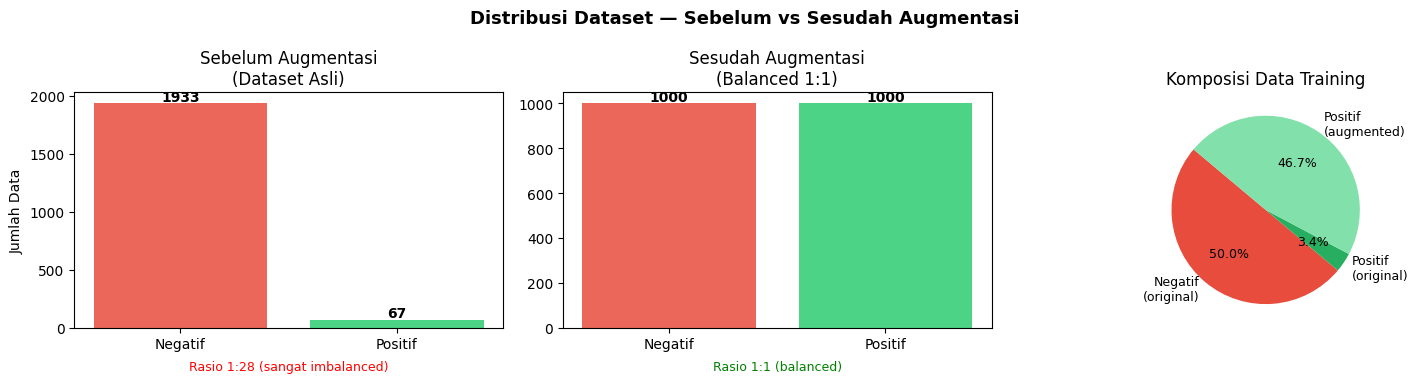

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Dataset — Sebelum vs Sesudah Augmentasi', fontsize=13, fontweight='bold')

# Before
axes[0].bar(['Negatif', 'Positif'], [1933, 67], color=['#e74c3c', '#2ecc71'], alpha=0.85)
axes[0].set_title('Sebelum Augmentasi\n(Dataset Asli)')
axes[0].set_ylabel('Jumlah Data')
for i, v in enumerate([1933, 67]):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[0].text(0.5, -0.18, 'Rasio 1:28 (sangat imbalanced)',
             ha='center', transform=axes[0].transAxes, color='red', fontsize=9)

# After
axes[1].bar(['Negatif', 'Positif'], [1000, 1000], color=['#e74c3c', '#2ecc71'], alpha=0.85)
axes[1].set_title('Sesudah Augmentasi\n(Balanced 1:1)')
for i, v in enumerate([1000, 1000]):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[1].text(0.5, -0.18, 'Rasio 1:1 (balanced)',
             ha='center', transform=axes[1].transAxes, color='green', fontsize=9)

# Komposisi augmented
labels = ['Negatif\n(original)', 'Positif\n(original)', 'Positif\n(augmented)']
sizes  = [1000, 67, 933]
colors = ['#e74c3c', '#27ae60', '#82e0aa']
axes[2].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 9})
axes[2].set_title('Komposisi Data Training')

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/plots/distribusi_sebelum_sesudah.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Plot disimpan ke Drive")


### Load IndoBERT Tokenizer & Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = 'indobenchmark/indobert-base-p1'
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Load tokenizer (skip jika sudah ada di Drive)
TOK_PATH = f'{MODEL_DIR}/tokenizer'
if os.path.exists(TOK_PATH):
    tokenizer = AutoTokenizer.from_pretrained(TOK_PATH)
    print("Tokenizer loaded dari Drive")
else:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    tokenizer.save_pretrained(TOK_PATH)
    print("Tokenizer downloaded & disimpan ke Drive")

Device: cuda
Tokenizer loaded dari Drive


In [ ]:
# Dataset Class & DataLoader

from torch.utils.data import Dataset as TorchDataset, DataLoader

class SentimenDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long),
        }

BATCH_SIZE = 16

train_ds = SentimenDataset(X_train, y_train, tokenizer)
test_ds  = SentimenDataset(X_test,  y_test,  tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"DataLoader siap")
print(f"Train: {len(train_ds)} sampel ({len(train_loader)} batch)")
print(f"Test : {len(test_ds)} sampel ({len(test_loader)} batch)")


DataLoader siap
Train: 2533 sampel (159 batch)
Test : 397 sampel (25 batch)


### Fine-Tune IndoBERT (Balanced Dataset)

In [ ]:
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, classification_report

SAVED_MODEL = f'{MODEL_DIR}/best_model.pt'
EPOCHS      = 5
LR          = 2e-5

def evaluate(mdl, loader):
    mdl.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbl  = batch['label'].to(device)
            out  = mdl(input_ids=ids, attention_mask=mask)
            pred = out.logits.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(lbl.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return acc, f1, all_labels, all_preds

if os.path.exists(SAVED_MODEL):
    print("Model sudah ada di Drive — skip training, load langsung")
    bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    bert_model.load_state_dict(torch.load(SAVED_MODEL, map_location=device))
    bert_model.to(device)
    acc, f1, y_true, y_pred = evaluate(bert_model, test_loader)
    print(f"   Accuracy: {acc:.4f} | F1: {f1:.4f}")
else:
    bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    bert_model.to(device)

    # Tidak pakai class_weight karena dataset sudah balanced
    optimizer  = AdamW(bert_model.parameters(), lr=LR, weight_decay=0.01)
    total_step = len(train_loader) * EPOCHS
    scheduler  = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_step),
        num_training_steps=total_step
    )

    best_f1    = 0
    best_state = None
    history    = []

    print(f"Training {EPOCHS} epoch | {len(train_ds)} train | {len(test_ds)} test")
    print(f"Dataset: BALANCED ")
    print("-" * 65)

    for epoch in range(1, EPOCHS + 1):
        bert_model.train()
        total_loss = 0
        for batch in train_loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbl  = batch['label'].to(device)
            optimizer.zero_grad()
            out  = bert_model(input_ids=ids, attention_mask=mask, labels=lbl)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        avg_loss           = total_loss / len(train_loader)
        acc, f1, yt, yp    = evaluate(bert_model, test_loader)

        history.append({'epoch': epoch, 'train_loss': avg_loss, 'val_acc': acc, 'val_f1': f1})
        print(f"Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1    = f1
            best_state = bert_model.state_dict().copy()
            y_true, y_pred = yt, yp

    bert_model.load_state_dict(best_state)
    torch.save(best_state, SAVED_MODEL)
    print(f"\n Model terbaik disimpan (F1={best_f1:.4f})")


Model sudah ada di Drive — skip training, load langsung


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Accuracy: 0.9874 | F1: 0.9866


In [ ]:
# Evaluasi & Perbandingan dengan Model Imbalanced

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

print("=" * 65)
print("HASIL INDOBERT — BALANCED DATASET")
print("=" * 65)
report = classification_report(y_true, y_pred,
                                target_names=['negatif', 'positif'],
                                digits=4)
print(report)

acc_bal = accuracy_score(y_true, y_pred)
pre_bal = precision_score(y_true, y_pred, average='weighted')
rec_bal = recall_score(y_true, y_pred, average='weighted')
f1_bal  = f1_score(y_true, y_pred, average='weighted')

print("=" * 65)
print("PERBANDINGAN: Imbalanced vs Balanced")
print("=" * 65)
print(f"{'Metrik':<15} {'Imbalanced (asli)':>20} {'Balanced (augmented)':>22}")
print("-" * 60)
for metrik, val_imb, val_bal in [
    ('Accuracy',  0.9875, acc_bal),
    ('Precision', 0.9868, pre_bal),
    ('Recall',    0.9875, rec_bal),
    ('F1-Score',  0.9867, f1_bal),
]:
    diff  = val_bal - val_imb
    arrow = '↑' if diff > 0 else ('↓' if diff < 0 else '→')
    print(f"{metrik:<15} {val_imb:>20.4f} {val_bal:>20.4f}  {arrow}{abs(diff):.4f}")
print("=" * 65)
print()


HASIL INDOBERT — BALANCED DATASET
              precision    recall  f1-score   support

     negatif     0.9897    0.9974    0.9935       384
     positif     0.9000    0.6923    0.7826        13

    accuracy                         0.9874       397
   macro avg     0.9448    0.8449    0.8881       397
weighted avg     0.9867    0.9874    0.9866       397

PERBANDINGAN: Imbalanced vs Balanced
Metrik             Imbalanced (asli)   Balanced (augmented)
------------------------------------------------------------
Accuracy                      0.9875               0.9874  ↓0.0001
Precision                     0.9868               0.9867  ↓0.0001
Recall                        0.9875               0.9874  ↓0.0001
F1-Score                      0.9867               0.9866  ↓0.0001



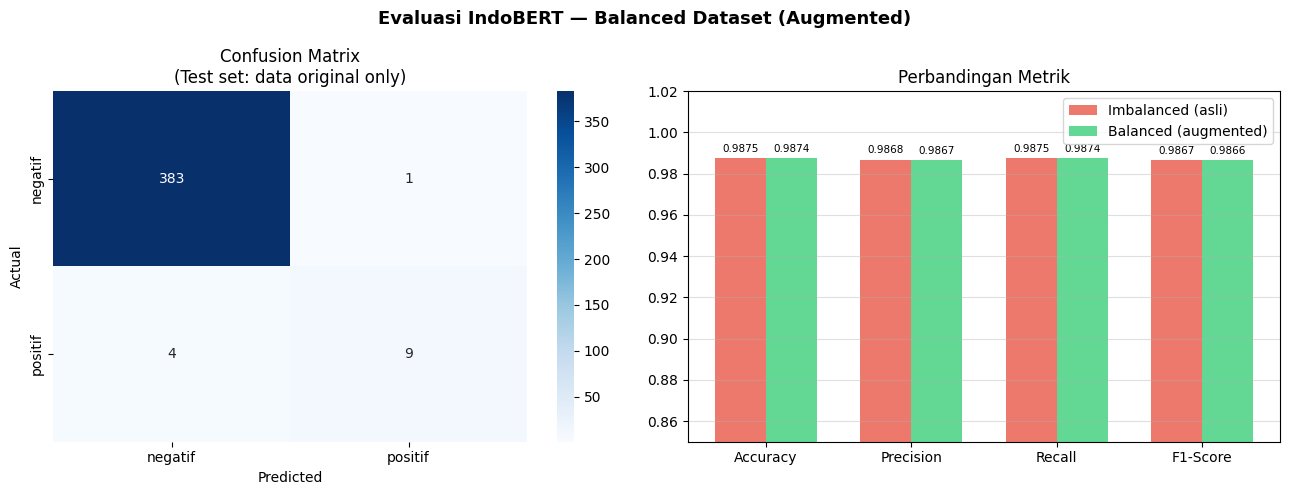

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Evaluasi IndoBERT — Balanced Dataset (Augmented)', fontsize=13, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['negatif','positif'], yticklabels=['negatif','positif'])
axes[0].set_title(f'Confusion Matrix\n(Test set: data original only)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Bar perbandingan metrik
metrik_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
vals_imb     = [0.9875, 0.9868, 0.9875, 0.9867]
vals_bal     = [acc_bal, pre_bal, rec_bal, f1_bal]

x   = range(len(metrik_names))
w   = 0.35
b1  = axes[1].bar([i - w/2 for i in x], vals_imb, w, label='Imbalanced (asli)', color='#e74c3c', alpha=0.75)
b2  = axes[1].bar([i + w/2 for i in x], vals_bal, w, label='Balanced (augmented)', color='#2ecc71', alpha=0.75)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(metrik_names)
axes[1].set_ylim(0.85, 1.02)
axes[1].set_title('Perbandingan Metrik')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.002, f'{h:.4f}',
                 ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
# plt.savefig(f'{OUTPUT_DIR}/plots/eval_balanced_vs_imbalanced.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Plot disimpan ke Drive")


In [ ]:
import numpy as np

y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)

fn_idx = np.where((y_true_arr == 1) & (y_pred_arr == 0))[0]
fp_idx = np.where((y_true_arr == 0) & (y_pred_arr == 1))[0]

print("Indeks FN:", fn_idx)
print("Indeks FP:", fp_idx)

# Cek atribut yang tersedia di test_ds
print("\nAtribut test_ds:", [a for a in dir(test_ds) if not a.startswith('_')])

Indeks FN: [ 35 304 329 374]
Indeks FP: [282]

Atribut test_ds: ['labels', 'max_len', 'texts', 'tokenizer']


In [ ]:
print("=== FALSE NEGATIVE (positif → salah prediksi negatif) ===")
for i, idx in enumerate(fn_idx):
    print(f"\n[FN-{i+1}] indeks {idx}:")
    print(f"  Teks   : {test_ds.texts[idx]}")
    print(f"  Label  : {test_ds.labels[idx]} (positif)")
    print(f"  Prediksi: {y_pred_arr[idx]} (negatif)")

print("\n=== FALSE POSITIVE (negatif → salah prediksi positif) ===")
for i, idx in enumerate(fp_idx):
    print(f"\n[FP-{i+1}] indeks {idx}:")
    print(f"  Teks   : {test_ds.texts[idx]}")
    print(f"  Label  : {test_ds.labels[idx]} (negatif)")
    print(f"  Prediksi: {y_pred_arr[idx]} (positif)")

=== FALSE NEGATIVE (positif → salah prediksi negatif) ===

[FN-1] indeks 35:
  Teks   : saya mau baca
  Label  : 1 (positif)
  Prediksi: 0 (negatif)

[FN-2] indeks 304:
  Teks   : saya sangat puas dengan aplikasi ini namun waktu melihat review nya saya kaget untungnya mungkin waktu giliran saya menggunakan kebetulan aplikasi sudah di perbaiki mungkin semoga aplikasi terus memerbaiki jika ada kesalahan seneng banget bisa baca buku tanpa ngeluarin uang
  Label  : 1 (positif)
  Prediksi: 0 (negatif)

[FN-3] indeks 329:
  Teks   : tidak bisa dibuka app nya udah versi terbaru padahal
  Label  : 1 (positif)
  Prediksi: 0 (negatif)

[FN-4] indeks 374:
  Teks   : lekas membaik ipusnas
  Label  : 1 (positif)
  Prediksi: 0 (negatif)

=== FALSE POSITIVE (negatif → salah prediksi positif) ===

[FP-1] indeks 282:
  Teks   : masih belum lancar
  Label  : 0 (negatif)
  Prediksi: 1 (positif)


In [ ]:
import json

# Simpan metrics single split ke Drive
single_split_metrics = {
    'accuracy' : float(accuracy_score(y_true, y_pred)),
    'precision': float(precision_score(y_true, y_pred, average='weighted')),
    'recall'   : float(recall_score(y_true, y_pred, average='weighted')),
    'f1_weighted': float(f1_score(y_true, y_pred, average='weighted')),
    'f1_macro' : float(f1_score(y_true, y_pred, average='macro')),
    'n_test'   : len(y_true),
}

save_path = f'{MODEL_DIR}/single_split_metrics.json'
with open(save_path, 'w') as f:
    json.dump(single_split_metrics, f, indent=2)

print(f"Metrics disimpan: {save_path}")
print(json.dumps(single_split_metrics, indent=2))


Metrics disimpan: /content/drive/MyDrive/skripsi/analisis sentimen/models/indobert_balanced/single_split_metrics.json
{
  "accuracy": 0.9874055415617129,
  "precision": 0.9867279792240251,
  "recall": 0.9874055415617129,
  "f1_weighted": 0.9866086666749053,
  "f1_macro": 0.8880618056730389,
  "n_test": 397
}


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, precision_score, recall_score)

# ── TF-IDF + SVM, data split identik dengan IndoBERT ──────────────────────────
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)   # X_train dari single split
X_test_tfidf  = tfidf.transform(X_test)

svm = SVC(kernel='linear', C=1.0, random_state=42, class_weight='balanced')
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

# ── Hasil SVM ──────────────────────────────────────────────────────────────────
print("=" * 65)
print("HASIL SVM BASELINE (TF-IDF + Linear SVC)")
print("=" * 65)
print(classification_report(y_test, y_pred_svm,
                             target_names=['negatif', 'positif'],
                             digits=4))

acc_svm = accuracy_score(y_test, y_pred_svm)
pre_svm = precision_score(y_test, y_pred_svm, average='weighted')
rec_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1w_svm = f1_score(y_test, y_pred_svm, average='weighted')
f1m_svm = f1_score(y_test, y_pred_svm, average='macro')

# ── Perbandingan SVM vs IndoBERT ───────────────────────────────────────────────
print("=" * 65)
print("PERBANDINGAN: SVM Baseline vs IndoBERT")
print("=" * 65)
print(f"{'Metrik':<18} {'SVM (TF-IDF)':>15} {'IndoBERT':>12} {'Δ':>8}")
print("-" * 55)
for metrik, svm_val, bert_val in [
    ('Accuracy',       acc_svm, accuracy_score(y_true, y_pred)),
    ('Precision (w)',  pre_svm, precision_score(y_true, y_pred, average='weighted')),
    ('Recall (w)',     rec_svm, recall_score(y_true, y_pred, average='weighted')),
    ('F1-Score (w)',   f1w_svm, f1_score(y_true, y_pred, average='weighted')),
    ('F1-Score (m)',   f1m_svm, f1_score(y_true, y_pred, average='macro')),
]:
    diff  = bert_val - svm_val
    arrow = '↑' if diff > 0 else '↓'
    print(f"{metrik:<18} {svm_val:>15.4f} {bert_val:>12.4f} {arrow}{abs(diff):>6.4f}")
print("=" * 65)

HASIL SVM BASELINE (TF-IDF + Linear SVC)
              precision    recall  f1-score   support

     negatif     0.9721    0.9974    0.9846       384
     positif     0.6667    0.1538    0.2500        13

    accuracy                         0.9698       397
   macro avg     0.8194    0.5756    0.6173       397
weighted avg     0.9621    0.9698    0.9605       397

PERBANDINGAN: SVM Baseline vs IndoBERT
Metrik                SVM (TF-IDF)     IndoBERT        Δ
-------------------------------------------------------
Accuracy                    0.9698       0.9874 ↑0.0176
Precision (w)               0.9621       0.9867 ↑0.0246
Recall (w)                  0.9698       0.9874 ↑0.0176
F1-Score (w)                0.9605       0.9866 ↑0.0261
F1-Score (m)                0.6173       0.8881 ↑0.2708
